# UK EV Charging Access Segmentation and Rollout Prioritisation

## Project Overview

This project combines official UK data on public EV chargers, plug-in vehicles, and local authority population to identify patterns of EV charging access across local authorities.

The goal is to build a local-authority level analytical view of charger supply, EV demand pressure, and relative charging access. Unsupervised learning techniques are then used to segment local authorities, compare structural patterns, and identify areas that may deserve closer rollout attention.

## Analytical Strategy

This project uses multiple unsupervised learning methods, but they do not all play the same role.

The analytical strategy is structured as follows:

- **Main segmentation method:** PCA followed by K-Means, used to identify the primary broad local-authority EV charging access patterns
- **Hierarchical comparison:** Agglomerative Clustering and a dendrogram, used to check whether a similar broad structure appears under a different clustering logic
- **Atypical-authority detection:** DBSCAN, used to identify authorities that fall outside the dominant dense national pattern
- **Nonlinear visual support:** t-SNE, used as a supporting visual tool to inspect whether the cluster and atypical-authority structure remains visible in a nonlinear embedding

This approach keeps the project decision-led rather than method-led. K-Means provides the main segmentation, while the other methods are used to validate, compare, or refine the interpretation.

## Business Problem

Public EV charger counts alone do not fully describe charging access.

A local authority may have a relatively high number of chargers in absolute terms, but still experience infrastructure pressure if it also has a large number of plug-in vehicles or a large population. Conversely, some areas may appear weak in raw charger counts while looking more reasonable after population-based normalisation.

The objective of this project is to identify broad EV charging access patterns across UK local authorities, detect atypical areas, and support a more informed view of rollout prioritisation.

## Project Objectives

This project aims to:

- combine charger, vehicle, and population data at local authority level
- build charger access and EV demand pressure features
- reduce feature redundancy using PCA
- segment local authorities using clustering methods
- compare clustering perspectives using K-Means and Agglomerative Clustering
- detect atypical local authorities using DBSCAN
- support practical rollout interpretation using business-facing outputs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

In [2]:
ev_file = "evci0102_2026-01_EV_chargers_by_local_authority_and_county_UK.ods"
veh_file = "veh0142.ods"
pop_file = "mye24tablesuk.xlsx"

## Loading the Three Core Datasets

The project uses three official data sources:

- public EV charger counts by local authority
- licensed plug-in vehicle counts by local authority
- local authority population estimates

These datasets will first be inspected and cleaned separately before being merged into one analytical table.

In [3]:
!pip install odfpy

Defaulting to user installation because normal site-packages is not writeable


In [4]:
ev_raw = pd.read_excel(ev_file, sheet_name="EVCI0102e", engine="odf")
veh_raw = pd.read_excel(veh_file, sheet_name="VEH0142", engine="odf")
pop_raw = pd.read_excel(pop_file, sheet_name="MYE2 - Persons")

## Initial Inspection

The first step is to inspect the shape and first rows of each dataset in order to confirm the sheet structure, geography fields, and value columns required for the project.

In [5]:
print("EV raw shape:", ev_raw.shape)
print("Vehicle raw shape:", veh_raw.shape)
print("Population raw shape:", pop_raw.shape)

EV raw shape: (1446, 8)
Vehicle raw shape: (25728, 71)
Population raw shape: (411, 95)


In [6]:
ev_raw.head(10)

,"EVCI0102e: Public electric vehicle chargers by local authority and county: United Kingdom, 1 January 2026; machine-readable format [notes 1, 2, 3]",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,This worksheet contains one table. Some cells ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Date,Notes,Local authority code,Local authority,County code,County,Key,Value
2,2026-01-01 00:00:00,[no note],E07000223,Adur,E10000032,West Sussex,EV chargers,103
3,2026-01-01 00:00:00,[no note],E07000223,Adur,E10000032,West Sussex,50kW+ EV chargers,33
4,2026-01-01 00:00:00,[no note],E07000223,Adur,E10000032,West Sussex,EV chargers per 100k,158.732605
5,2026-01-01 00:00:00,[no note],E07000223,Adur,E10000032,West Sussex,50kW+ EV chargers per 100k,50.856077
6,2026-01-01 00:00:00,[no note],E07000032,Amber Valley,E10000007,Derbyshire,EV chargers,102
7,2026-01-01 00:00:00,[no note],E07000032,Amber Valley,E10000007,Derbyshire,50kW+ EV chargers,30
8,2026-01-01 00:00:00,[no note],E07000032,Amber Valley,E10000007,Derbyshire,EV chargers per 100k,78.190278
9,2026-01-01 00:00:00,[no note],E07000032,Amber Valley,E10000007,Derbyshire,50kW+ EV chargers per 100k,22.997141


In [7]:
veh_raw.head(10)

,"Licensed plug-in vehicles (PiVs) [note 1] at the end of the quarter [note 2] by body type, fuel type, keepership [note 3] and upper and lower tier local authority [note 4] [note 5], Great Britian from 2009 Q4 (end December); United Kingdom from 2014 Q3 (end September)",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69,Unnamed: 70
0,Table VEH0142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,This worksheet contains 1 table. Some cells re...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Some shorthand is used in this table, [z] = no...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Units,BodyType,Fuel,Keepership,ONS Sort,ONS Code,ONS Geography,2025 Q3,2025 Q2,2025 Q1,...,2012 Q1,2011 Q4,2011 Q3,2011 Q2,2011 Q1,2010 Q4,2010 Q3,2010 Q2,2010 Q1,2009 Q4
4,Number,Buses and coaches,BATTERY ELECTRIC,COMPANY,1,K02000001,United Kingdom,7037,6406,5777,...,[x],[x],[x],[x],[x],[x],[x],[x],[x],[x]
5,Number,Buses and coaches,BATTERY ELECTRIC,COMPANY,2,K03000001,Great Britain,6772,6161,5531,...,54,58,57,59,58,49,45,41,40,38
6,Number,Buses and coaches,BATTERY ELECTRIC,COMPANY,3,E92000001,England,5689,5188,4636,...,51,55,54,57,55,46,43,39,38,36
7,Number,Buses and coaches,BATTERY ELECTRIC,COMPANY,4,E12000001,North East,127,107,76,...,7,12,12,13,14,7,5,4,4,4
8,Number,Buses and coaches,BATTERY ELECTRIC,COMPANY,5,E06000047,County Durham,1,1,1,...,0,0,3,3,3,3,1,0,0,0
9,Number,Buses and coaches,BATTERY ELECTRIC,COMPANY,6,E06000003,Redcar and Cleveland,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [8]:
pop_raw.head(15)

,"MYE2: Persons by single year of age and sex for local authorities in the UK, mid-2024",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 85,Unnamed: 86,Unnamed: 87,Unnamed: 88,Unnamed: 89,Unnamed: 90,Unnamed: 91,Unnamed: 92,Unnamed: 93,Unnamed: 94
0,This worksheet contains one table. Freeze pane...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,To turn off freeze panes select the 'View' rib...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Please choose from the links presented in the ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"This met my needs, please produce it next year",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,I need something slightly different (please sp...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,This is not what I need all all (please specify),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Code,Name,Geography,All ages,0.0,1.0,2.0,3.0,4.0,5.0,...,81.0,82.0,83.0,84.0,85.0,86.0,87.0,88.0,89.0,90+
7,K02000001,UNITED KINGDOM,Country,69281437,667994.0,690113.0,732532.0,728400.0,755117.0,769993.0,...,414914.0,357410.0,305273.0,300816.0,281337.0,256103.0,224742.0,195365.0,167231.0,625236
8,K03000001,GREAT BRITAIN,Country,67353582,648105.0,669724.0,710426.0,706322.0,732313.0,746520.0,...,403452.0,347774.0,296936.0,293200.0,274184.0,249746.0,219033.0,190506.0,163096.0,610585
9,K04000001,ENGLAND AND WALES,Country,61806682,601329.0,622020.0,660624.0,656038.0,680640.0,692020.0,...,369527.0,318021.0,271613.0,268602.0,251783.0,229508.0,201631.0,175142.0,149932.0,563609


## Cleaning the EV Charger Dataset

The raw EV charger sheet includes title and note rows above the actual table header.  
This step resets the correct header row, keeps the relevant charger metrics, and reshapes the data into one row per local authority.

In [9]:
# Reset correct header row for EV data
ev = ev_raw.copy()
ev.columns = ev.iloc[1]
ev = ev.iloc[2:].reset_index(drop=True)

# Keep only the columns we need
ev = ev[["Local authority code", "Local authority", "Key", "Value"]].copy()

# Convert Value to numeric
ev["Value"] = pd.to_numeric(ev["Value"], errors="coerce")

# Keep only the four charger metrics we need
ev = ev[ev["Key"].isin([
    "EV chargers",
    "50kW+ EV chargers",
    "EV chargers per 100k",
    "50kW+ EV chargers per 100k"
])].copy()

# Pivot from long to wide
ev_clean = ev.pivot_table(
    index=["Local authority code", "Local authority"],
    columns="Key",
    values="Value",
    aggfunc="first"
).reset_index()

# Rename columns cleanly
ev_clean = ev_clean.rename(columns={
    "Local authority code": "la_code",
    "Local authority": "la_name",
    "EV chargers": "ev_chargers",
    "50kW+ EV chargers": "fast_chargers_50kw_plus",
    "EV chargers per 100k": "ev_chargers_per_100k",
    "50kW+ EV chargers per 100k": "fast_chargers_per_100k"
})

ev_clean.columns.name = None


print(ev_clean.shape)
ev_clean.head()

(361, 6)


,la_code,la_name,fast_chargers_50kw_plus,fast_chargers_per_100k,ev_chargers,ev_chargers_per_100k
0,E06000001,Hartlepool,17.0,17.315135,87.0,88.612752
1,E06000002,Middlesbrough,39.0,24.974225,140.0,89.651065
2,E06000003,Redcar and Cleveland,31.0,22.265636,140.0,100.554486
3,E06000004,Stockton-on-Tees,57.0,27.562863,268.0,129.593810
4,E06000005,Darlington,10.0,8.889758,160.0,142.236130


## Cleaning the Plug-in Vehicle Dataset

The vehicle file contains multiple breakdowns by body type, fuel type, keepership, and geography level.  
For this project, only the total plug-in vehicle count by local authority for a recent quarter is required.

In [10]:
# Reset correct header row for vehicle data
veh = veh_raw.copy()
veh.columns = veh.iloc[3]
veh = veh.iloc[4:].reset_index(drop=True)

# Keep only columns needed for this project
veh = veh[[
    "BodyType", "Fuel", "Keepership",
    "ONS Code", "ONS Geography", "2025 Q3"
]].copy()

# Rename columns
veh = veh.rename(columns={
    "ONS Code": "la_code",
    "ONS Geography": "la_name",
    "2025 Q3": "plug_in_vehicles_q3_2025"
})

# Convert quarter values to numeric
veh["plug_in_vehicles_q3_2025"] = pd.to_numeric(veh["plug_in_vehicles_q3_2025"], errors="coerce")

# Filter to total rows only
veh_clean = veh[
    (veh["BodyType"].astype(str).str.strip().str.upper() == "TOTAL") &
    (veh["Fuel"].astype(str).str.strip().str.upper() == "TOTAL") &
    (veh["Keepership"].astype(str).str.strip().str.upper() == "TOTAL")
].copy()

veh_clean.columns.name = None
veh_clean.head(10)

print(veh_clean.shape)
veh_clean.head(10)

(447, 6)


,BodyType,Fuel,Keepership,la_code,la_name,plug_in_vehicles_q3_2025
25277,Total,Total,Total,K02000001,United Kingdom,2623482
25278,Total,Total,Total,K03000001,Great Britain,2581041
25279,Total,Total,Total,E92000001,England,2317401
25280,Total,Total,Total,E12000001,North East,54190
25281,Total,Total,Total,E06000047,County Durham,10464
25282,Total,Total,Total,E06000005,Darlington,5100
25283,Total,Total,Total,E06000001,Hartlepool,1462
25284,Total,Total,Total,E06000002,Middlesbrough,2010
25285,Total,Total,Total,E06000057,Northumberland,8258
25286,Total,Total,Total,E06000003,Redcar and Cleveland,2046


## Cleaning the Population Dataset

The population file also includes title and note rows above the real table header.  
For this project, only the geography code, geography name, geography type, and total population are required.

In [11]:
# Reset correct header row for population data
pop = pop_raw.copy()
pop.columns = pop.iloc[6]
pop = pop.iloc[7:].reset_index(drop=True)

# Keep only relevant columns
pop = pop[["Code", "Name", "Geography", "All ages"]].copy()

# Rename columns
pop = pop.rename(columns={
    "Code": "la_code",
    "Name": "la_name",
    "Geography": "geography_type",
    "All ages": "population_total"
})

# Convert population to numeric
pop["population_total"] = pd.to_numeric(pop["population_total"], errors="coerce")

print(pop.shape)
pop.head(10)

(404, 4)


6,la_code,la_name,geography_type,population_total
0,K02000001,UNITED KINGDOM,Country,69281437
1,K03000001,GREAT BRITAIN,Country,67353582
2,K04000001,ENGLAND AND WALES,Country,61806682
3,E92000001,ENGLAND,Country,58620101
4,E12000001,NORTH EAST,Region,2760678
5,E06000047,County Durham,Unitary Authority,538011
6,E06000005,Darlington,Unitary Authority,112489
7,E06000001,Hartlepool,Unitary Authority,98180
8,E06000002,Middlesbrough,Unitary Authority,156161
9,E06000057,Northumberland,Unitary Authority,331420


## Filtering to Local Authority Level

The cleaned tables still include geography levels such as the United Kingdom, Great Britain, England, and regions.

For this project, the analytical unit is the local authority. This step removes higher-level geographies so that the merged dataset represents one row per local authority.

In [12]:
# Clean display artifacts
ev_clean.columns.name = None
veh_clean.columns.name = None
pop.columns.name = None

# Keep only local-authority-like geography rows in population file
pop_la = pop[
    pop["geography_type"].isin([
        "Unitary Authority",
        "Metropolitan District",
        "London Borough",
        "Non-metropolitan District",
        "Metropolitan County",
        "Council Area",
        "District Council",
        "County"
    ])
].copy()

# For vehicle file, keep only rows whose codes look like local authority codes
veh_la = veh_clean[
    veh_clean["la_code"].astype(str).str.startswith(("E06", "E07", "E08", "E09", "W06", "S12", "N09"))
].copy()

print("EV table shape:", ev_clean.shape)
print("Vehicle LA shape:", veh_la.shape)
print("Population LA shape:", pop_la.shape)

EV table shape: (361, 6)
Vehicle LA shape: (361, 6)
Population LA shape: (377, 4)


In [13]:
veh_la.head(10)

,BodyType,Fuel,Keepership,la_code,la_name,plug_in_vehicles_q3_2025
25281,Total,Total,Total,E06000047,County Durham,10464
25282,Total,Total,Total,E06000005,Darlington,5100
25283,Total,Total,Total,E06000001,Hartlepool,1462
25284,Total,Total,Total,E06000002,Middlesbrough,2010
25285,Total,Total,Total,E06000057,Northumberland,8258
25286,Total,Total,Total,E06000003,Redcar and Cleveland,2046
25287,Total,Total,Total,E06000004,Stockton-on-Tees,4245
25289,Total,Total,Total,E08000037,Gateshead,3440
25290,Total,Total,Total,E08000021,Newcastle upon Tyne,5234
25291,Total,Total,Total,E08000022,North Tyneside,4446


In [14]:
pop_la.head(10)

,la_code,la_name,geography_type,population_total
5,E06000047,County Durham,Unitary Authority,538011
6,E06000005,Darlington,Unitary Authority,112489
7,E06000001,Hartlepool,Unitary Authority,98180
8,E06000002,Middlesbrough,Unitary Authority,156161
9,E06000057,Northumberland,Unitary Authority,331420
10,E06000003,Redcar and Cleveland,Unitary Authority,139228
11,E06000004,Stockton-on-Tees,Unitary Authority,206800
12,E11000007,Tyne and Wear (Met County),Metropolitan County,1178389
13,E08000037,Gateshead,Metropolitan District,202760
14,E08000021,Newcastle upon Tyne,Metropolitan District,320605


## Merging the Cleaned Datasets

The charger, vehicle, and population tables are now merged into a single local-authority level analytical dataset.

The merge is performed using local authority codes so that all supply, demand, and population measures are aligned consistently.

In [15]:
df = ev_clean.merge(
    veh_la[["la_code", "la_name", "plug_in_vehicles_q3_2025"]],
    on="la_code",
    how="inner",
    suffixes=("_ev", "_veh")
)

df = df.merge(
    pop_la[["la_code", "la_name", "geography_type", "population_total"]],
    on="la_code",
    how="inner",
    suffixes=("", "_pop")
)

print(df.shape)
df.head(10)

(350, 11)


,la_code,la_name_ev,fast_chargers_50kw_plus,fast_chargers_per_100k,ev_chargers,ev_chargers_per_100k,la_name_veh,plug_in_vehicles_q3_2025,la_name,geography_type,population_total
0,E06000001,Hartlepool,17.0,17.315135,87.0,88.612752,Hartlepool,1462,Hartlepool,Unitary Authority,98180
1,E06000002,Middlesbrough,39.0,24.974225,140.0,89.651065,Middlesbrough,2010,Middlesbrough,Unitary Authority,156161
2,E06000003,Redcar and Cleveland,31.0,22.265636,140.0,100.554486,Redcar and Cleveland,2046,Redcar and Cleveland,Unitary Authority,139228
3,E06000004,Stockton-on-Tees,57.0,27.562863,268.0,129.593810,Stockton-on-Tees,4245,Stockton-on-Tees,Unitary Authority,206800
4,E06000005,Darlington,10.0,8.889758,160.0,142.236130,Darlington,5100,Darlington,Unitary Authority,112489
5,E06000006,Halton,10.0,7.602077,80.0,60.816615,Halton,4578,Halton,Unitary Authority,131543
6,E06000007,Warrington,115.0,53.391274,290.0,134.638866,Warrington,6699,Warrington,Unitary Authority,215391
7,E06000008,Blackburn with Darwen,46.0,28.300726,110.0,67.675649,Blackburn with Darwen,2964,Blackburn with Darwen,Unitary Authority,162540
8,E06000009,Blackpool,28.0,19.418688,145.0,100.561061,Blackpool,1926,Blackpool,Unitary Authority,144191
9,E06000010,"Kingston upon Hull, City of",76.0,27.596123,260.0,94.407791,"Kingston upon Hull, City of",3543,"Kingston upon Hull, City of",Unitary Authority,275401


## Sanity Checks After Merge

Before feature engineering, the merged local-authority dataset is checked for missing values and duplicate authority codes.

This helps confirm that the analytical table is structurally valid before unsupervised learning is applied.

In [16]:
print(df.isnull().sum())
print("\nDuplicate la_code count:", df["la_code"].duplicated().sum())

la_code                     0
la_name_ev                  0
fast_chargers_50kw_plus     0
fast_chargers_per_100k      0
ev_chargers                 0
ev_chargers_per_100k        0
la_name_veh                 0
plug_in_vehicles_q3_2025    0
la_name                     0
geography_type              0
population_total            0
dtype: int64

Duplicate la_code count: 0


In [17]:
# keep one clean local authority name column
df["la_name"] = df["la_name_ev"]

# drop duplicate name columns if present
drop_cols = [c for c in ["la_name_ev", "la_name_veh"] if c in df.columns]
df = df.drop(columns=drop_cols)

# reorder columns
df = df[
    [
        "la_code",
        "la_name",
        "geography_type",
        "ev_chargers",
        "fast_chargers_50kw_plus",
        "ev_chargers_per_100k",
        "fast_chargers_per_100k",
        "plug_in_vehicles_q3_2025",
        "population_total"
    ]
].copy()

df.head()

,la_code,la_name,geography_type,ev_chargers,fast_chargers_50kw_plus,ev_chargers_per_100k,fast_chargers_per_100k,plug_in_vehicles_q3_2025,population_total
0,E06000001,Hartlepool,Unitary Authority,87.0,17.0,88.612752,17.315135,1462,98180
1,E06000002,Middlesbrough,Unitary Authority,140.0,39.0,89.651065,24.974225,2010,156161
2,E06000003,Redcar and Cleveland,Unitary Authority,140.0,31.0,100.554486,22.265636,2046,139228
3,E06000004,Stockton-on-Tees,Unitary Authority,268.0,57.0,129.593810,27.562863,4245,206800
4,E06000005,Darlington,Unitary Authority,160.0,10.0,142.236130,8.889758,5100,112489


## Feature Engineering for EV Charging Access Pressure

The merged table provides raw charger supply, plug-in vehicle counts, and population totals by local authority.

To support segmentation and rollout prioritisation, additional analytical features are created to capture charger access, fast-charger access, EV pressure, and supply-demand balance.

In [18]:
df["plug_in_vehicles_per_100k"] = (
    df["plug_in_vehicles_q3_2025"] / df["population_total"] * 100000
)

df["plug_in_vehicles_per_charger"] = (
    df["plug_in_vehicles_q3_2025"] / df["ev_chargers"]
)

df["plug_in_vehicles_per_fast_charger"] = (
    df["plug_in_vehicles_q3_2025"] / df["fast_chargers_50kw_plus"]
)

df["chargers_per_vehicle"] = (
    df["ev_chargers"] / df["plug_in_vehicles_q3_2025"]
)

df["fast_chargers_share"] = (
    df["fast_chargers_50kw_plus"] / df["ev_chargers"]
)

df.head()

,la_code,la_name,geography_type,ev_chargers,fast_chargers_50kw_plus,ev_chargers_per_100k,fast_chargers_per_100k,plug_in_vehicles_q3_2025,population_total,plug_in_vehicles_per_100k,plug_in_vehicles_per_charger,plug_in_vehicles_per_fast_charger,chargers_per_vehicle,fast_chargers_share
0,E06000001,Hartlepool,Unitary Authority,87.0,17.0,88.612752,17.315135,1462,98180,1489.101650,16.804598,86.000000,0.059508,0.195402
1,E06000002,Middlesbrough,Unitary Authority,140.0,39.0,89.651065,24.974225,2010,156161,1287.133151,14.357143,51.538462,0.069652,0.278571
2,E06000003,Redcar and Cleveland,Unitary Authority,140.0,31.0,100.554486,22.265636,2046,139228,1469.531991,14.614286,66.000000,0.068426,0.221429
3,E06000004,Stockton-on-Tees,Unitary Authority,268.0,57.0,129.593810,27.562863,4245,206800,2052.707930,15.839552,74.473684,0.063133,0.212687
4,E06000005,Darlington,Unitary Authority,160.0,10.0,142.236130,8.889758,5100,112489,4533.776636,31.875000,510.000000,0.031373,0.062500


In [19]:
feature_cols = [
    "ev_chargers",
    "fast_chargers_50kw_plus",
    "ev_chargers_per_100k",
    "fast_chargers_per_100k",
    "plug_in_vehicles_q3_2025",
    "population_total",
    "plug_in_vehicles_per_100k",
    "plug_in_vehicles_per_charger",
    "plug_in_vehicles_per_fast_charger",
    "chargers_per_vehicle",
    "fast_chargers_share"
]

df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
ev_chargers,350.0,3.284114e+02,385.619454,16.000000,138.250000,205.500000,367.250000,2.875000e+03
fast_chargers_50kw_plus,350.0,7.444571e+01,57.269495,0.000000,35.250000,59.500000,95.000000,3.980000e+02
ev_chargers_per_100k,350.0,1.743530e+02,153.173471,38.444949,97.608859,137.235208,193.503701,1.469630e+03
fast_chargers_per_100k,350.0,4.065906e+01,22.709921,0.000000,24.766077,35.347417,52.055072,1.383551e+02
plug_in_vehicles_q3_2025,350.0,7.236831e+03,15440.210096,91.000000,2683.250000,3962.500000,6186.500000,1.580290e+05
population_total,350.0,1.924388e+05,132234.061775,2366.000000,108616.250000,147356.000000,240679.500000,1.183618e+06
plug_in_vehicles_per_100k,350.0,3.653922e+03,6892.263258,1127.105034,1963.992132,2460.422037,3207.063164,9.942495e+04
plug_in_vehicles_per_charger,350.0,2.840143e+01,56.684075,2.144617,12.489005,18.822280,28.482906,8.062704e+02
plug_in_vehicles_per_fast_charger,350.0,inf,NaN,9.472222,45.899685,71.171201,113.818296,inf
chargers_per_vehicle,350.0,6.932886e-02,0.061387,0.001240,0.035109,0.053129,0.080070,4.662836e-01


In [20]:
print(df[feature_cols].isnull().sum())
print(np.isinf(df[feature_cols]).sum())

ev_chargers                          0
fast_chargers_50kw_plus              0
ev_chargers_per_100k                 0
fast_chargers_per_100k               0
plug_in_vehicles_q3_2025             0
population_total                     0
plug_in_vehicles_per_100k            0
plug_in_vehicles_per_charger         0
plug_in_vehicles_per_fast_charger    0
chargers_per_vehicle                 0
fast_chargers_share                  0
dtype: int64
ev_chargers                          0
fast_chargers_50kw_plus              0
ev_chargers_per_100k                 0
fast_chargers_per_100k               0
plug_in_vehicles_q3_2025             0
population_total                     0
plug_in_vehicles_per_100k            0
plug_in_vehicles_per_charger         0
plug_in_vehicles_per_fast_charger    1
chargers_per_vehicle                 0
fast_chargers_share                  0
dtype: int64


## Handling Infinite Values

One engineered feature, `plug_in_vehicles_per_fast_charger`, produced an infinite value where a local authority had plug-in vehicles but no fast chargers.

This is meaningful from a business perspective, but infinite values cannot be used directly in scaling or unsupervised learning. The value is therefore replaced with a missing value and then imputed using the median of the valid observations.

In [21]:
df["no_fast_charger_flag"] = (df["fast_chargers_50kw_plus"] == 0).astype(int)

df["plug_in_vehicles_per_fast_charger"] = df["plug_in_vehicles_per_fast_charger"].replace([np.inf, -np.inf], np.nan)

df["plug_in_vehicles_per_fast_charger"] = df["plug_in_vehicles_per_fast_charger"].fillna(
    df["plug_in_vehicles_per_fast_charger"].median()
)

## Selecting the Final Modelling Features

The engineered dataset contains both raw counts and normalized access-pressure measures. For unsupervised learning, the final modelling feature set focuses on normalized and ratio-based variables that better reflect charger access, EV demand pressure, and charger mix quality.

This avoids overloading the analysis with redundant raw totals and keeps the modelling space more aligned with the business question.

In [22]:
model_features = [
    "ev_chargers_per_100k",
    "fast_chargers_per_100k",
    "plug_in_vehicles_per_100k",
    "plug_in_vehicles_per_charger",
    "plug_in_vehicles_per_fast_charger",
    "fast_chargers_share"
]

X = df[model_features].copy()

print(X.shape)
X.head()

(350, 6)


,ev_chargers_per_100k,fast_chargers_per_100k,plug_in_vehicles_per_100k,plug_in_vehicles_per_charger,plug_in_vehicles_per_fast_charger,fast_chargers_share
0,88.612752,17.315135,1489.101650,16.804598,86.000000,0.195402
1,89.651065,24.974225,1287.133151,14.357143,51.538462,0.278571
2,100.554486,22.265636,1469.531991,14.614286,66.000000,0.221429
3,129.593810,27.562863,2052.707930,15.839552,74.473684,0.212687
4,142.236130,8.889758,4533.776636,31.875000,510.000000,0.062500


## Scaling the Modelling Features

The selected modelling variables are measured on different numeric scales. Standardisation is therefore required before applying PCA and clustering so that no single variable dominates the analysis purely because of its magnitude.

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)
X_scaled[:5]

(350, 6)


array([[-0.56056028, -1.02938918, -0.31454397, -0.20488009, -0.09163329,
        -0.66006528],
       [-0.5537719 , -0.69164891, -0.34388957, -0.24811901, -0.16678529,
        -0.10835388],
       [-0.48248651, -0.81108864, -0.3173874 , -0.2435761 , -0.13524829,
        -0.48741719],
       [-0.29263054, -0.57749865, -0.23265314, -0.22192944, -0.1167693 ,
        -0.54540822],
       [-0.20997642, -1.40092016,  0.12784103,  0.06136714,  0.83300467,
        -1.54168701]])

## Applying PCA

The engineered EV access-pressure feature space contains multiple related variables, including charger availability, fast-charger availability, EV presence, and supply-demand pressure ratios.

PCA is applied here to reduce redundancy across these correlated variables and identify the main dimensions that explain how local authorities differ in charging access patterns.

In [24]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)
X_pca[:5]

(350, 6)


array([[-0.25403774,  0.75485383, -1.13701701, -0.16787848,  0.04977623,
         0.0325342 ],
       [-0.3760441 ,  0.1866077 , -0.90773557,  0.00342274, -0.03143027,
         0.05663451],
       [-0.3238102 ,  0.55871163, -0.93207726, -0.13515837,  0.02813629,
         0.04183916],
       [-0.27006421,  0.57247803, -0.62475603, -0.19656491,  0.05293212,
         0.03460116],
       [ 0.71908449,  1.77454107, -1.08166624, -0.42932783, -0.26498821,
         0.08276928]])

In [25]:
pca_cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]
X_pca_df = pd.DataFrame(X_pca, columns=pca_cols)

X_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6
0,-0.254038,0.754854,-1.137017,-0.167878,0.049776,0.032534
1,-0.376044,0.186608,-0.907736,0.003423,-0.031430,0.056635
2,-0.323810,0.558712,-0.932077,-0.135158,0.028136,0.041839
3,-0.270064,0.572478,-0.624756,-0.196565,0.052932,0.034601
4,0.719084,1.774541,-1.081666,-0.429328,-0.264988,0.082769


## Explained Variance

After fitting PCA, the next step is to measure how much variance each principal component explains.

This helps determine whether the six engineered EV access-pressure variables can be represented well using a smaller number of principal components without losing too much information.

In [26]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

variance_df = pd.DataFrame({
    "Principal_Component": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained_Variance_Ratio": explained_variance,
    "Cumulative_Explained_Variance": cumulative_variance
})

variance_df

,Principal_Component,Explained_Variance_Ratio,Cumulative_Explained_Variance
0,PC1,0.459756,0.459756
1,PC2,0.270249,0.730005
2,PC3,0.200186,0.930191
3,PC4,0.038091,0.968281
4,PC5,0.026900,0.995181
5,PC6,0.004819,1.000000


## Visualising Cumulative Explained Variance

A cumulative explained variance plot helps show how quickly the principal components capture the structure of the engineered EV charging access-pressure feature space.

This makes it easier to decide how many components should be retained for downstream clustering.

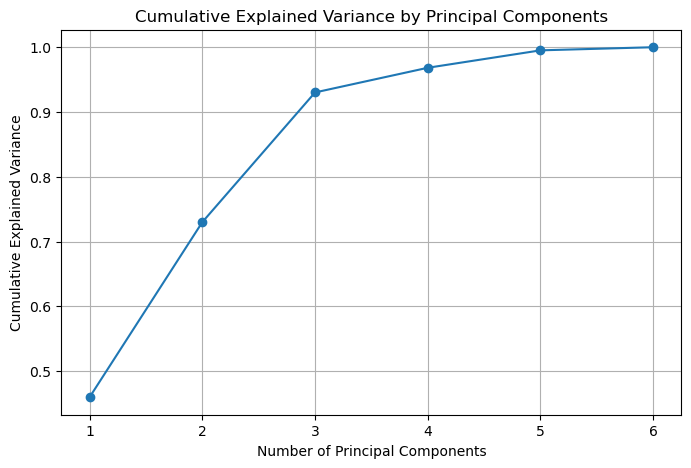

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o')
plt.xticks(range(1, len(explained_variance) + 1))
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by Principal Components")
plt.grid(True)
plt.show()

## Component Loadings

To interpret the principal components, the loading matrix is examined.

The loadings show how strongly each original EV access-pressure variable contributes to each principal component, helping translate the PCA output into meaningful infrastructure and demand-pressure patterns.

In [28]:
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=model_features
)

loadings_df

,PC1,PC2,PC3,PC4,PC5,PC6
ev_chargers_per_100k,-0.025457,0.447227,0.711899,0.529777,-0.071658,-0.082100
fast_chargers_per_100k,-0.065020,-0.472780,0.682066,-0.540153,-0.003364,-0.123534
plug_in_vehicles_per_100k,0.579662,-0.035718,0.160236,0.004067,0.405440,0.687490
plug_in_vehicles_per_charger,0.582880,-0.112157,-0.047295,0.126863,0.366880,-0.703378
plug_in_vehicles_per_fast_charger,0.564450,0.081720,-0.005365,-0.142906,-0.808834,0.007422
fast_chargers_share,-0.027624,-0.745610,-0.006631,0.625330,-0.204107,0.102770


### PCA Interpretation Summary

The explained variance results show that the first three principal components capture most of the structure in the engineered EV charging access-pressure feature space.

- `PC1` explains the largest share of variance and is mainly associated with EV demand pressure, especially through variables such as plug-in vehicles per 100,000 population and vehicles per charger.
- `PC2` appears to capture charger composition and fast-charger mix, reflecting how the infrastructure profile differs across local authorities.
- `PC3` is driven mainly by charger availability measures, especially total chargers and fast chargers per 100,000 population.

Together, these results suggest that local authorities differ mainly along three dimensions: EV pressure, charger mix, and charger availability. For downstream clustering, retaining the first three principal components provides strong dimensionality reduction with limited information loss.

## Selecting the Reduced PCA Space

Based on the explained variance results, the first three principal components are retained for downstream clustering.

This preserves most of the original structure in the EV charging access-pressure data while reducing the feature space from six engineered variables to three principal dimensions.

In [29]:
X_pca_3 = X_pca_df[["PC1", "PC2", "PC3"]].copy()

print(X_pca_3.shape)
X_pca_3.head()

(350, 3)


,PC1,PC2,PC3
0,-0.254038,0.754854,-1.137017
1,-0.376044,0.186608,-0.907736
2,-0.323810,0.558712,-0.932077
3,-0.270064,0.572478,-0.624756
4,0.719084,1.774541,-1.081666


## Choosing the Number of Clusters for K-Means

Before fitting the final K-Means model, multiple values of `k` are tested on the reduced PCA space.

This helps assess how many broad local-authority access patterns are supported by the data, using both inertia and silhouette score.

In [30]:
k_values = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca_3)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca_3, labels))

cluster_eval_df = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias,
    "Silhouette_Score": silhouette_scores
})

cluster_eval_df

,k,Inertia,Silhouette_Score
0,2,1259.699141,0.914365
1,3,925.936417,0.304733
2,4,712.626907,0.403375
3,5,517.347203,0.395546
4,6,407.036511,0.323292
5,7,347.148991,0.337285
6,8,300.439970,0.351231


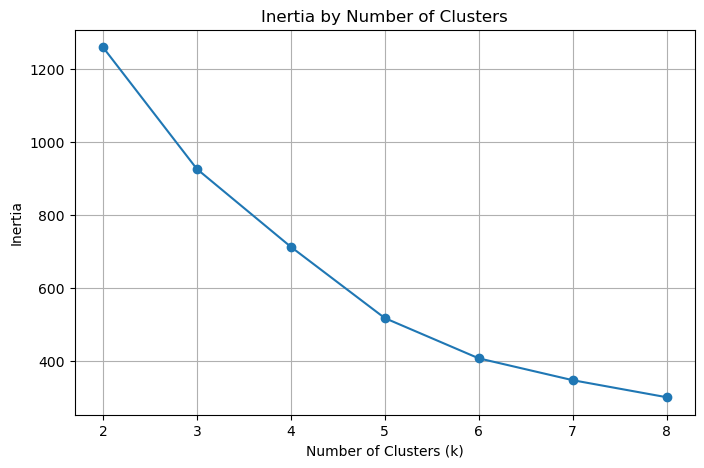

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(cluster_eval_df["k"], cluster_eval_df["Inertia"], marker='o')
plt.xticks(cluster_eval_df["k"])
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Inertia by Number of Clusters")
plt.grid(True)
plt.show()

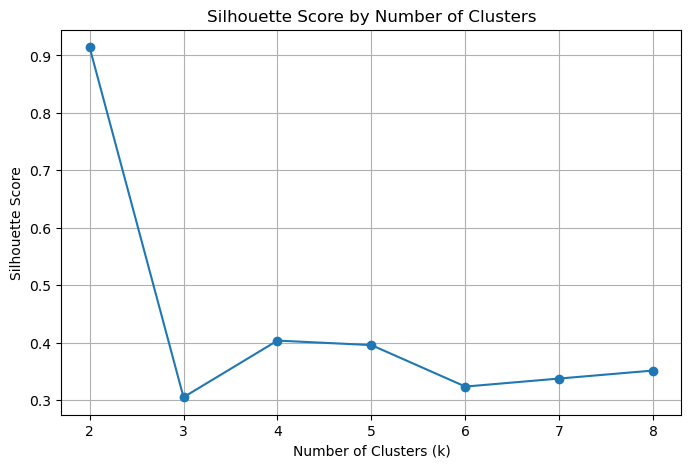

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(cluster_eval_df["k"], cluster_eval_df["Silhouette_Score"], marker='o')
plt.xticks(cluster_eval_df["k"])
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.grid(True)
plt.show()

### Interpreting the Cluster Evaluation Results

The silhouette score is highest at **k = 2**, but the resulting two-cluster solution is highly imbalanced and separates one local authority into a singleton cluster while placing nearly all other authorities into the second group.

This suggests that the two-cluster solution is mainly capturing an extreme outlier rather than producing a practically useful broad segmentation. For this reason, a higher-k solution is explored for the main segmentation. Among the non-trivial alternatives, **k = 4** provides the strongest silhouette score and is selected as the main K-Means clustering solution.

In [33]:
final_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_pca_3)

df["Cluster"] = cluster_labels
X_pca_3["Cluster"] = cluster_labels

print(df["Cluster"].value_counts().sort_index())

Cluster
0    236
1     24
2     89
3      1
Name: count, dtype: int64


In [34]:
# singleton authority

df[df["Cluster"] == 3][["la_code", "la_name"] + model_features]

,la_code,la_name,ev_chargers_per_100k,fast_chargers_per_100k,plug_in_vehicles_per_100k,plug_in_vehicles_per_charger,plug_in_vehicles_per_fast_charger,fast_chargers_share
37,E06000040,Windsor and Maidenhead,123.314647,11.953971,99424.951083,806.270408,8317.315789,0.096939


### Handling the Singleton Authority

The K-Means results show that **Windsor and Maidenhead** forms a singleton cluster, meaning it behaves very differently from the rest of the local authorities in the EV access-pressure feature space.

Rather than treating this as a normal broad segment, it is treated as an atypical authority. The main K-Means segmentation is therefore re-run on the remaining local authorities.

### Why Windsor and Maidenhead Was Treated Separately

The initial K-Means results showed that **Windsor and Maidenhead** formed a singleton cluster, meaning it was separated entirely from the rest of the local authorities.

This indicates that the authority behaves as an extreme case in the EV access-pressure feature space rather than as part of a broad mainstream group. If left inside the main segmentation, it would distort the broader clustering structure and reduce the usefulness of the final group interpretation.

For this reason, Windsor and Maidenhead is treated as an **atypical authority** and removed from the main K-Means segmentation. It is then brought back later as a separate analytical finding rather than being forced into one of the broad authority groups.

In [35]:
# remove the singleton authority from the main segmentation table
df_main = df[df["la_name"] != "Windsor and Maidenhead"].copy()
X_pca_main = X_pca_3.loc[df_main.index, ["PC1", "PC2", "PC3"]].copy()

print(df_main.shape)
print(X_pca_main.shape)

(349, 16)
(349, 3)


## Re-running K-Means on the Main Authority Set

After removing the singleton authority, K-Means is re-run on the remaining local authorities using **k = 3**.

This aims to identify the main broad EV charging access patterns without allowing one extreme authority to dominate the segmentation structure.

In [36]:
final_kmeans_main = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels_main = final_kmeans_main.fit_predict(X_pca_main)

df_main["Cluster"] = cluster_labels_main
X_pca_main["Cluster"] = cluster_labels_main

print(df_main["Cluster"].value_counts().sort_index())

Cluster
0     25
1    230
2     94
Name: count, dtype: int64


## Visualising the Final K-Means Segmentation

After removing the singleton authority and re-running K-Means with **k = 3**, the resulting cluster structure is visualised in the reduced PCA space.

This helps assess whether the three broad EV charging access patterns are reasonably separated across the first two principal components.

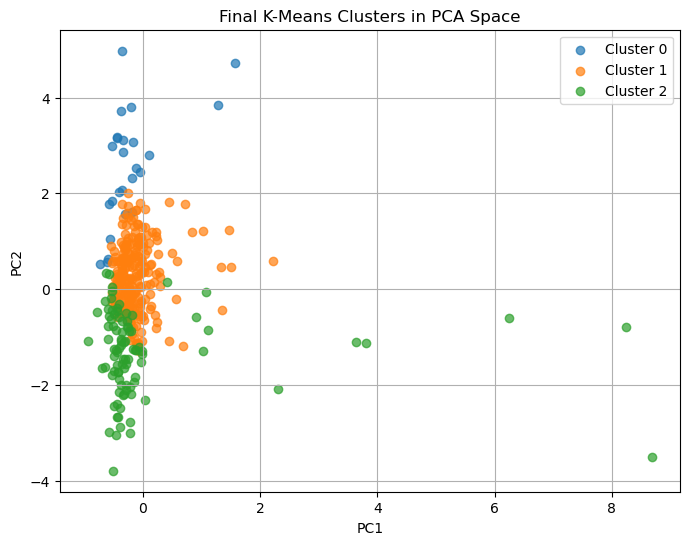

In [43]:
plt.figure(figsize=(8, 6))

for cluster in sorted(X_pca_main["Cluster"].unique()):
    cluster_data = X_pca_main[X_pca_main["Cluster"] == cluster]
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Final K-Means Clusters in PCA Space")
plt.legend()
plt.grid(True)
plt.show()

## Profiling the Final Clusters

Although the final clustering was performed in the PCA-reduced space, the three groups need to be interpreted using the original EV access-pressure variables.

This step compares the average feature values of each cluster so that the three local-authority patterns can be translated into meaningful infrastructure and demand-pressure profiles.

In [38]:
cluster_profile = df_main.groupby("Cluster")[model_features].mean()
cluster_profile

,ev_chargers_per_100k,fast_chargers_per_100k,plug_in_vehicles_per_100k,plug_in_vehicles_per_charger,plug_in_vehicles_per_fast_charger,fast_chargers_share
Cluster,,,,,,
0,590.213121,33.928576,3495.779428,5.729602,158.618837,0.068912
1,131.204756,30.596706,2658.796210,24.059631,104.858760,0.259396
2,169.870235,67.375120,5112.023567,36.779532,89.429857,0.444002


In [39]:
cluster_sizes = df_main["Cluster"].value_counts().sort_index().rename("Local_Authority_Count")
cluster_sizes

Cluster
0     25
1    230
2     94
Name: Local_Authority_Count, dtype: int64

### Cluster Profile Interpretation

The cluster means show that the three local-authority groups represent different EV charging access and demand-pressure patterns.

- **Cluster 0** is a smaller group of 25 authorities with very high total charger availability per 100,000 population and the lowest plug-in vehicle pressure per charger. However, it has a relatively weak fast-charger share. This suggests a charger-rich group with broad supply strength but a less fast-charger-heavy infrastructure mix.
- **Cluster 1** is the largest group of 230 authorities and shows the lowest overall charger availability and lower EV presence per 100,000 population. This appears to represent the mainstream national pattern of more moderate EV charging provision and access pressure.
- **Cluster 2** contains 94 authorities and shows the highest plug-in vehicle intensity, the highest pressure per charger, and the strongest fast-charger presence and fast-charger share. This suggests a group of high-EV, high-pressure authorities with more fast-charger-intensive infrastructure.

Overall, the segmentation suggests that UK local authorities differ mainly across three broad patterns: charger-rich lower-pressure areas, mainstream lower-supply areas, and high-EV high-pressure areas with stronger fast-charger intensity.

### Cluster names

Cluster 0 → Charger-Rich Lower-Pressure Authorities

Cluster 1 → Mainstream Lower-Supply Authorities

Cluster 2 → High-EV High-Pressure Authorities

## Assigning Business-Friendly Segment Names

To make the clustering output easier to interpret, each cluster is mapped to a business-friendly label based on its EV charging access and demand-pressure profile.

In [40]:
segment_map = {
    0: "Charger-Rich Lower-Pressure Authorities",
    1: "Mainstream Lower-Supply Authorities",
    2: "High-EV High-Pressure Authorities"
}

df_main["Segment_Name"] = df_main["Cluster"].map(segment_map)

df_main[["la_code", "la_name", "Cluster", "Segment_Name"]].head(10)

,la_code,la_name,Cluster,Segment_Name
0,E06000001,Hartlepool,1,Mainstream Lower-Supply Authorities
1,E06000002,Middlesbrough,1,Mainstream Lower-Supply Authorities
2,E06000003,Redcar and Cleveland,1,Mainstream Lower-Supply Authorities
3,E06000004,Stockton-on-Tees,1,Mainstream Lower-Supply Authorities
4,E06000005,Darlington,1,Mainstream Lower-Supply Authorities
5,E06000006,Halton,1,Mainstream Lower-Supply Authorities
6,E06000007,Warrington,2,High-EV High-Pressure Authorities
7,E06000008,Blackburn with Darwen,1,Mainstream Lower-Supply Authorities
8,E06000009,Blackpool,1,Mainstream Lower-Supply Authorities
9,E06000010,"Kingston upon Hull, City of",1,Mainstream Lower-Supply Authorities


## Final Segment Summary Table

A final summary table is created to combine:

- cluster size
- business-friendly segment label
- mean EV charging access-pressure profile

This provides a compact and business-readable view of the final segmentation.

In [41]:
segment_summary = df_main.groupby(["Cluster", "Segment_Name"])[model_features].mean().reset_index()

segment_counts = df_main.groupby(["Cluster", "Segment_Name"]).size().reset_index(name="Local_Authority_Count")

final_summary = segment_counts.merge(segment_summary, on=["Cluster", "Segment_Name"])

final_summary

,Cluster,Segment_Name,Local_Authority_Count,ev_chargers_per_100k,fast_chargers_per_100k,plug_in_vehicles_per_100k,plug_in_vehicles_per_charger,plug_in_vehicles_per_fast_charger,fast_chargers_share
0,0,Charger-Rich Lower-Pressure Authorities,25,590.213121,33.928576,3495.779428,5.729602,158.618837,0.068912
1,1,Mainstream Lower-Supply Authorities,230,131.204756,30.596706,2658.796210,24.059631,104.858760,0.259396
2,2,High-EV High-Pressure Authorities,94,169.870235,67.375120,5112.023567,36.779532,89.429857,0.444002


## Business Interpretation

The final K-Means segmentation suggests that UK local authorities fall into three broad EV charging access patterns.

- **Charger-Rich Lower-Pressure Authorities** have very strong overall charger availability relative to population and lower EV pressure per charger, but a weaker fast-charger share.
- **Mainstream Lower-Supply Authorities** represent the largest group and show lower overall provision and more moderate access-pressure conditions.
- **High-EV High-Pressure Authorities** show the strongest EV intensity and the highest pressure per charger, while also having the strongest fast-charger presence and fast-charger share.

This suggests that local authorities are not simply divided by charger count alone. Instead, they differ across a combination of charger availability, EV intensity, infrastructure pressure, and fast-charger mix.

## Atypical Authority Insight

Before the final three-cluster segmentation was fitted, one local authority formed a singleton cluster under K-Means, indicating highly unusual EV charging access-pressure behaviour relative to the rest of the dataset.

This authority is treated as an atypical case rather than as a broad segment, which strengthens the project by separating mainstream segmentation from unusual-area detection.

In [42]:
singleton_authority = df[df["la_name"] == "Windsor and Maidenhead"][
    ["la_code", "la_name"] + model_features
].copy()

singleton_authority

,la_code,la_name,ev_chargers_per_100k,fast_chargers_per_100k,plug_in_vehicles_per_100k,plug_in_vehicles_per_charger,plug_in_vehicles_per_fast_charger,fast_chargers_share
37,E06000040,Windsor and Maidenhead,123.314647,11.953971,99424.951083,806.270408,8317.315789,0.096939


## Rollout Prioritisation Implications

The segmentation has practical implications for charger rollout and infrastructure planning.

- **High-EV High-Pressure Authorities** may deserve priority attention because they combine strong EV presence with the highest charger pressure, suggesting potentially greater infrastructure strain.
- **Mainstream Lower-Supply Authorities** may represent broader medium-term rollout candidates where provision remains relatively limited across a large number of authorities.
- **Charger-Rich Lower-Pressure Authorities** appear better served overall, although their weaker fast-charger share may still matter depending on travel patterns and charging needs.
- **Atypical authorities** such as Windsor and Maidenhead should be reviewed separately rather than grouped into mainstream rollout logic, as their behaviour may reflect unusual local dynamics.

## Limitations

This project has several important limitations.

- The analysis uses charger counts, plug-in vehicle counts, and population totals, but it does not directly observe charger utilisation, queueing, or real-time availability.
- Licensed plug-in vehicle counts are used as a demand-side proxy, but local authority registration totals may not perfectly reflect actual public charging behaviour in all areas.
- The results depend on the engineered feature set and the selected clustering parameters, so different modelling choices could lead to somewhat different group boundaries.
- The project is designed as a strategic local-authority level analysis and does not include finer-grained charger location, station-level utilisation, or temporal demand variation.

These limitations do not invalidate the analysis, but they mean the results should be interpreted as a decision-support view of EV charging access patterns rather than as a complete operational model.

## Agglomerative Clustering

To compare the K-Means segmentation with a hierarchical clustering approach, Agglomerative Clustering is applied to the same three-component PCA space.

This helps assess whether a similar broad local-authority structure appears under a different clustering logic that does not rely on centroids.

In [44]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3, linkage="ward")
agg_labels = agg.fit_predict(X_pca_main[["PC1", "PC2", "PC3"]])

df_main["Agg_Cluster"] = agg_labels
X_pca_main["Agg_Cluster"] = agg_labels

print(df_main["Agg_Cluster"].value_counts().sort_index())

Agg_Cluster
0     66
1    260
2     23
Name: count, dtype: int64


## Dendrogram

A dendrogram is used to visualise the hierarchical merge structure of the local authorities in the reduced PCA space.

This helps show how authorities are grouped step by step and whether a three-cluster cut looks reasonable from a hierarchical perspective.

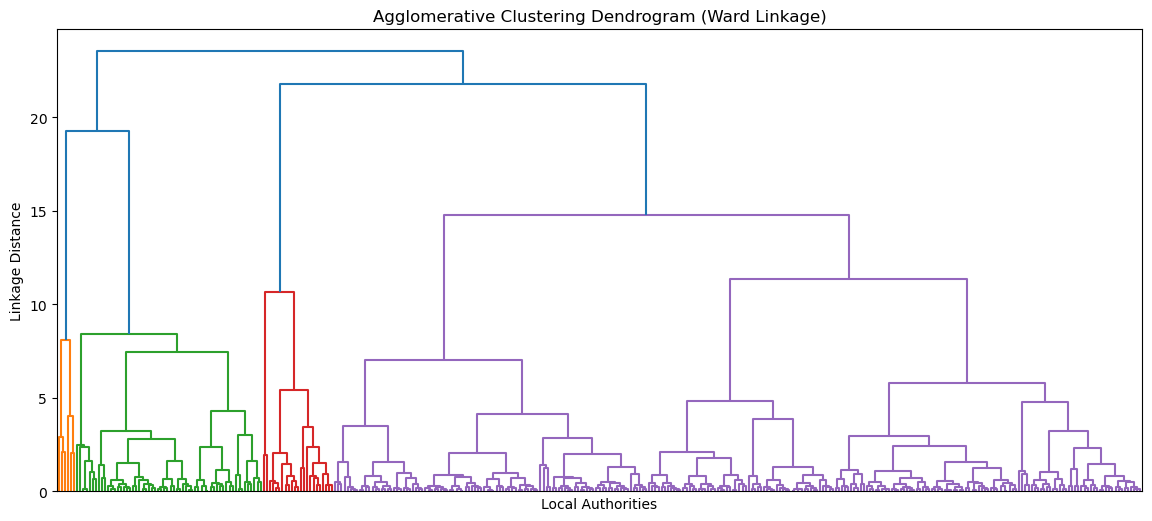

In [45]:
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(X_pca_main[["PC1", "PC2", "PC3"]], method="ward")

plt.figure(figsize=(14, 6))
dendrogram(linked, no_labels=True)
plt.title("Agglomerative Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Local Authorities")
plt.ylabel("Linkage Distance")
plt.show()

## Profiling the Agglomerative Clusters

Although Agglomerative Clustering was fitted in the reduced PCA space, the resulting groups need to be interpreted using the original EV access-pressure variables.

This step compares the average feature values of each hierarchical cluster so that the groups can be translated into meaningful infrastructure and demand-pressure patterns.

In [46]:
agg_profile = df_main.groupby("Agg_Cluster")[model_features].mean()
agg_profile

,ev_chargers_per_100k,fast_chargers_per_100k,plug_in_vehicles_per_100k,plug_in_vehicles_per_charger,plug_in_vehicles_per_fast_charger,fast_chargers_share
Agg_Cluster,,,,,,
0,195.053168,75.878609,6251.957784,41.371766,104.803336,0.427832
1,131.797419,32.937770,2609.288951,24.042286,98.068283,0.283081
2,598.234175,28.126509,3843.629926,6.639143,177.157329,0.055735


In [47]:
agg_sizes = df_main["Agg_Cluster"].value_counts().sort_index().rename("Local_Authority_Count")
agg_sizes

Agg_Cluster
0     66
1    260
2     23
Name: Local_Authority_Count, dtype: int64

### Agglomerative Cluster Interpretation

The Agglomerative Clustering results suggest three broad local-authority patterns that closely resemble the K-Means segmentation.

- **Agglomerative Cluster 0** represents a high-EV, high-pressure group with the strongest EV intensity, the highest pressure per charger, and the strongest fast-charger presence.
- **Agglomerative Cluster 1** represents the largest mainstream group, with lower overall provision and more moderate EV charging access-pressure conditions.
- **Agglomerative Cluster 2** represents a charger-rich lower-pressure group with extremely high total charger availability and the lowest pressure per charger, but a weak fast-charger share.

Although the exact cluster sizes differ from the K-Means solution, the overall authority patterns are broadly consistent across the two methods. This strengthens the conclusion that the dataset contains three meaningful EV charging access structures rather than a pattern driven only by one clustering algorithm.

## DBSCAN for Atypical Authority Detection

DBSCAN is applied as a density-based comparison method to test whether the local-authority EV access-pressure space contains dense natural groups and to identify authorities that sit outside the dominant behavioural pattern.

In this project, DBSCAN is treated mainly as a supporting method for atypical-area detection rather than as the main segmentation approach.

In [48]:
eps_values = [0.5, 0.75, 1.0, 1.25, 1.5]
min_samples_values = [3, 5, 8]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_pca_main[["PC1", "PC2", "PC3"]])
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        
        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": n_noise
        })

dbscan_eval_df = pd.DataFrame(dbscan_results)
dbscan_eval_df

,eps,min_samples,n_clusters,n_noise
0,0.50,3,5,39
1,0.50,5,3,56
2,0.50,8,1,73
3,0.75,3,2,24
4,0.75,5,1,30
5,0.75,8,1,43
6,1.00,3,1,14
7,1.00,5,1,16
8,1.00,8,1,22
9,1.25,3,1,10


## Fitting the Final DBSCAN Model

Based on the parameter search, a DBSCAN model with `eps = 1.0` and `min_samples = 5` is selected for closer inspection.

This setting produces one dominant dense group together with a manageable number of noise-labelled authorities, making it suitable for atypical-area detection.

In [49]:
db_final = DBSCAN(eps=1.0, min_samples=5)
db_labels = db_final.fit_predict(X_pca_main[["PC1", "PC2", "PC3"]])

df_main["DBSCAN_Cluster"] = db_labels
X_pca_main["DBSCAN_Cluster"] = db_labels

print(df_main["DBSCAN_Cluster"].value_counts().sort_index())

DBSCAN_Cluster
-1     16
 0    333
Name: count, dtype: int64


## Visualising the DBSCAN Result

The DBSCAN result is plotted in the reduced PCA space to show the dominant dense authority group and the smaller set of noise-labelled authorities.

This helps assess whether the noise points appear as genuinely unusual cases relative to the main EV access-pressure structure.

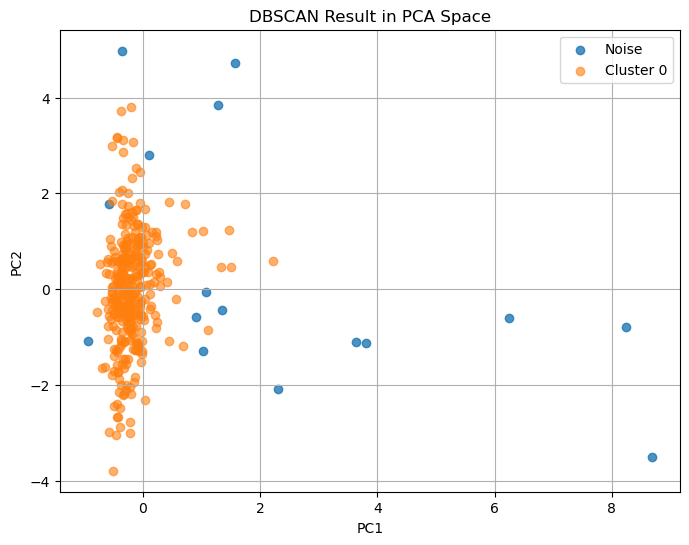

In [50]:
plt.figure(figsize=(8, 6))

for label in sorted(X_pca_main["DBSCAN_Cluster"].unique()):
    cluster_data = X_pca_main[X_pca_main["DBSCAN_Cluster"] == label]
    
    if label == -1:
        plt.scatter(
            cluster_data["PC1"],
            cluster_data["PC2"],
            label="Noise",
            alpha=0.8
        )
    else:
        plt.scatter(
            cluster_data["PC1"],
            cluster_data["PC2"],
            label=f"Cluster {label}",
            alpha=0.6
        )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Result in PCA Space")
plt.legend()
plt.grid(True)
plt.show()

## Inspecting Noise-Labelled Authorities

DBSCAN labels a subset of local authorities as noise, meaning that they do not belong to the dominant dense authority pattern under the chosen parameter setting.

These authorities are inspected directly to understand which cases appear most atypical in the EV access-pressure feature space.

In [51]:
dbscan_noise = df_main[df_main["DBSCAN_Cluster"] == -1].copy()

dbscan_noise[["la_code", "la_name"] + model_features].sort_values(
    by="plug_in_vehicles_per_charger",
    ascending=False
).head(20)

,la_code,la_name,ev_chargers_per_100k,fast_chargers_per_100k,plug_in_vehicles_per_100k,plug_in_vehicles_per_charger,plug_in_vehicles_per_fast_charger,fast_chargers_share
233,E08000007,Stockport,110.223111,71.069230,49113.115234,445.579104,691.060185,0.644776
28,E06000031,Peterborough,104.625428,32.192439,40604.949588,388.098291,1261.319444,0.307692
36,E06000039,Slough,97.395419,29.875896,30088.014388,308.926380,1007.100000,0.306748
27,E06000030,Swindon,121.373655,47.155305,23498.923629,193.608108,498.330435,0.388514
24,E06000025,South Gloucestershire,162.242273,79.978585,19730.227335,121.609658,246.693878,0.492958
217,E07000236,Redditch,48.948740,18.213485,5618.860064,114.790698,308.500000,0.372093
39,E06000042,Milton Keynes,333.786664,100.691766,36022.479110,107.920666,357.750000,0.301665
70,E07000034,Chesterfield,189.542175,75.439672,12340.987317,65.109453,163.587500,0.398010
318,S12000038,Renfrewshire,232.066395,70.835756,12083.311307,52.068337,170.582090,0.305239
313,S12000030,Stirling,460.672965,98.715635,17057.637194,37.027650,172.795699,0.214286


### DBSCAN Interpretation

The DBSCAN result suggests that the EV access-pressure space is dominated by one main dense local-authority structure rather than several large, well-separated density-based groups.

Using the selected parameter setting, DBSCAN identifies one large dense cluster containing most authorities together with a smaller set of noise-labelled authorities. These noise points represent authorities that do not fit the dominant national pattern in terms of charger availability, EV intensity, charger pressure, or fast-charger mix.

The noise-labelled authorities include two broad types of unusual cases:

- authorities with exceptionally high EV intensity and charger pressure
- authorities with unusually strong charger provision or unusually low pressure per charger

This shows that DBSCAN is more useful here as a supporting method for atypical-authority detection than as a primary segmentation method. In contrast to K-Means and Agglomerative Clustering, which recover broad authority patterns, DBSCAN highlights which local authorities sit outside the main dense EV access structure.

## t-SNE for Nonlinear Visual Exploration

t-SNE is applied as a nonlinear visualisation tool to examine whether the EV charging access-pressure structure becomes clearer in a two-dimensional nonlinear embedding.

Unlike PCA, which preserves linear variance structure, t-SNE focuses on preserving local neighbourhood relationships. In this project, it is used as a supporting visual comparison rather than as a main modelling method.

In [52]:
X_main = df_main[model_features].copy()

scaler_tsne = StandardScaler()
X_main_scaled = scaler_tsne.fit_transform(X_main)

print(X_main_scaled.shape)

(349, 6)


In [53]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate="auto", init="pca")
X_tsne = tsne.fit_transform(X_main_scaled)

tsne_df = pd.DataFrame(X_tsne, columns=["tSNE1", "tSNE2"], index=df_main.index)
tsne_df["Cluster"] = df_main["Cluster"].values
tsne_df["Agg_Cluster"] = df_main["Agg_Cluster"].values
tsne_df["DBSCAN_Cluster"] = df_main["DBSCAN_Cluster"].values
tsne_df["la_name"] = df_main["la_name"].values

tsne_df.head()

,tSNE1,tSNE2,Cluster,Agg_Cluster,DBSCAN_Cluster,la_name
0,6.342015,9.252814,1,1,0,Hartlepool
1,3.189377,-0.432897,1,1,0,Middlesbrough
2,4.905826,7.795230,1,1,0,Redcar and Cleveland
3,2.350714,7.000091,1,1,0,Stockton-on-Tees
4,16.910419,11.043591,1,1,0,Darlington


## Visualising the K-Means Segmentation in t-SNE Space

The t-SNE map is used to visualise the final K-Means segmentation in a nonlinear two-dimensional embedding.

This helps assess whether the three broad authority groups remain visually distinct when local neighbourhood structure is emphasised instead of linear variance structure.

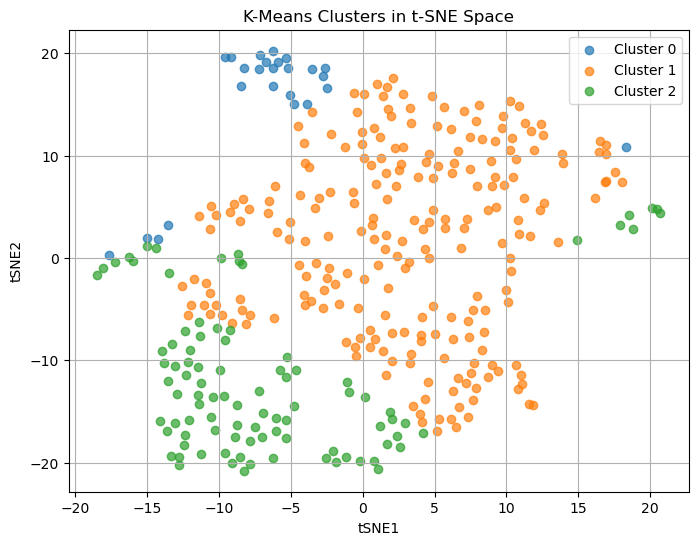

In [54]:
plt.figure(figsize=(8, 6))

for cluster in sorted(tsne_df["Cluster"].unique()):
    cluster_data = tsne_df[tsne_df["Cluster"] == cluster]
    plt.scatter(
        cluster_data["tSNE1"],
        cluster_data["tSNE2"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("tSNE1")
plt.ylabel("tSNE2")
plt.title("K-Means Clusters in t-SNE Space")
plt.legend()
plt.grid(True)
plt.show()

## Visualising Atypical Authorities in t-SNE Space

The t-SNE map is also used to show the DBSCAN result, highlighting which authorities lie outside the dominant dense EV access-pressure structure.

This provides a nonlinear visual check on the atypical-authority pattern identified by DBSCAN.

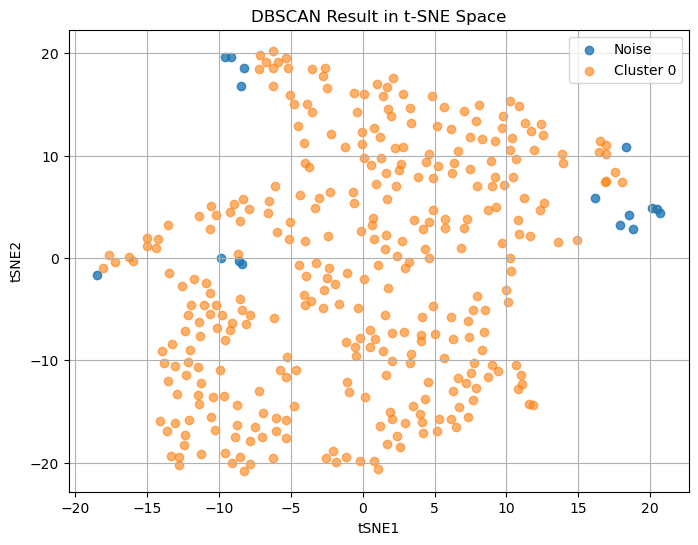

In [55]:
plt.figure(figsize=(8, 6))

for label in sorted(tsne_df["DBSCAN_Cluster"].unique()):
    subset = tsne_df[tsne_df["DBSCAN_Cluster"] == label]
    
    if label == -1:
        plt.scatter(
            subset["tSNE1"],
            subset["tSNE2"],
            label="Noise",
            alpha=0.8
        )
    else:
        plt.scatter(
            subset["tSNE1"],
            subset["tSNE2"],
            label=f"Cluster {label}",
            alpha=0.6
        )

plt.xlabel("tSNE1")
plt.ylabel("tSNE2")
plt.title("DBSCAN Result in t-SNE Space")
plt.legend()
plt.grid(True)
plt.show()

In [56]:
tsne_df.sort_values("tSNE1", ascending=False)[["la_name", "tSNE1", "tSNE2", "Cluster", "DBSCAN_Cluster"]].head(10)

,la_name,tSNE1,tSNE2,Cluster,DBSCAN_Cluster
233,Stockport,20.716805,4.341357,2,-1
28,Peterborough,20.445070,4.755567,2,-1
36,Slough,20.125057,4.839674,2,-1
39,Milton Keynes,18.774345,2.831461,2,-1
27,Swindon,18.545301,4.190907,2,-1
282,Kensington and Chelsea,18.337986,10.859891,0,-1
115,Rushmoor,18.014648,7.391383,1,0
24,South Gloucestershire,17.881603,3.195420,2,-1
41,Portsmouth,17.535677,8.356166,1,0
74,North East Derbyshire,16.959183,10.156001,1,0


In [57]:
tsne_df.sort_values("tSNE2", ascending=False)[["la_name", "tSNE1", "tSNE2", "Cluster", "DBSCAN_Cluster"]].head(10)

,la_name,tSNE1,tSNE2,Cluster,DBSCAN_Cluster
49,Isles of Scilly,-6.232254,20.245346,0,0
292,Tower Hamlets,-7.156891,19.795033,0,0
275,Hammersmith and Fulham,-9.179939,19.640516,0,-1
295,Westminster,-9.597686,19.600183,0,-1
274,Hackney,-5.326426,19.562174,0,0
290,Southwark,-5.877311,19.189785,0,0
293,Waltham Forest,-6.719524,19.130100,0,0
294,Wandsworth,-5.171957,18.589563,0,0
267,Brent,-2.617077,18.551796,0,0
289,Richmond upon Thames,-6.253542,18.525265,0,0


### t-SNE Interpretation

The t-SNE visualisation provides a useful nonlinear view of the EV charging access-pressure structure across local authorities.

When coloured by the final K-Means solution, the t-SNE map shows that the three broad clusters occupy meaningfully different regions of the nonlinear embedding. The groups are not perfectly separated, but the visual structure supports the idea that the segmentation is capturing real differences in local-authority charging access patterns.

When coloured by the DBSCAN result, the t-SNE map also shows that most authorities belong to one dominant dense body while a smaller set of noise-labelled authorities sit around the edges of the embedding. This supports the interpretation that DBSCAN is more useful here for atypical-authority detection than for broad segmentation.

Overall, t-SNE adds value as a supporting visual tool by confirming that the main segmentation and atypical-authority findings are not merely artifacts of one linear projection.

## Final Conclusion

This project combined official UK data on EV charger supply, plug-in vehicle counts, and population totals to build a local-authority level view of EV charging access and infrastructure pressure.

After engineering charger access and EV demand-pressure variables, PCA was used to reduce redundancy in the feature space and reveal the main structural dimensions of variation. K-Means clustering was then applied to identify broad local-authority patterns.

The final segmentation revealed three main authority types:

- charger-rich lower-pressure authorities
- mainstream lower-supply authorities
- high-EV high-pressure authorities

In addition, Windsor and Maidenhead emerged as a highly atypical authority, suggesting that some local areas may require separate review rather than inclusion in broad segmentation logic.

Overall, the project demonstrates how unsupervised learning can support more informed EV charging rollout interpretation by combining segmentation, dimensionality reduction, and atypical-area detection in a practical decision-support workflow.